# Maji Ndogo Farm Survey Analysis
## Exploring agricultural patterns across 5,654 farms in Maji Ndogo

This project analyses farm survey data from the Maji Ndogo region,
covering geographic, weather, soil, and farm management features.
The goal is to uncover what factors influence crop yield
and identify opportunities to improve agricultural output.

**Tools used:** Python, Pandas, SQLite, Matplotlib, Seaborn  
**Dataset:** Maji Ndogo Farm Survey (5,654 farms)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
conn = sqlite3.connect('Maji_Ndogo_farm_survey_small.db')
geo_df = pd.read_sql_query("SELECT * FROM geographic_features", conn)
weather_df = pd.read_sql_query("SELECT * FROM weather_features", conn)
soil_df = pd.read_sql_query("SELECT * FROM soil_and_crop_features", conn)
farm_df = pd.read_sql_query("SELECT * FROM farm_management_features", conn)

In [3]:
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)


,name
0,geographic_features
1,weather_features
2,soil_and_crop_features
3,farm_management_features


In [4]:
print(geo_df.shape)
display(geo_df.head())
print(geo_df.dtypes)
print(geo_df.isnull().sum())

(5654, 6)


,Field_ID,Elevation,Latitude,Longitude,Location,Slope
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656


Field_ID       int64
Elevation    float64
Latitude     float64
Longitude    float64
Location         str
Slope        float64
dtype: object
Field_ID     0
Elevation    0
Latitude     0
Longitude    0
Location     0
Slope        0
dtype: int64


In [5]:
print(weather_df.shape)
display(weather_df.head())
print(weather_df.dtypes)
print(weather_df.isnull().sum())

(5654, 5)


,Field_ID,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps
0,40734,1125.2,-3.1,33.1,15.00
1,30629,1450.7,-3.9,30.6,13.35
2,39924,2208.9,-1.8,28.4,13.30
3,5754,328.8,-5.8,32.2,13.20
4,14146,785.2,-2.5,31.0,14.25


Field_ID               int64
Rainfall             float64
Min_temperature_C    float64
Max_temperature_C    float64
Ave_temps            float64
dtype: object
Field_ID             0
Rainfall             0
Min_temperature_C    0
Max_temperature_C    0
Ave_temps            0
dtype: int64


In [6]:
print(soil_df.shape)
display(soil_df.head())
print(soil_df.dtypes)
print(soil_df.isnull().sum())

(5654, 4)


,Field_ID,Soil_fertility,Soil_type,pH
0,40734,0.62,Sandy,6.169393
1,30629,0.64,Volcanic,5.676648
2,39924,0.69,Volcanic,5.331993
3,5754,0.54,Loamy,5.328150
4,14146,0.72,Sandy,5.721234


Field_ID            int64
Soil_fertility    float64
Soil_type             str
pH                float64
dtype: object
Field_ID          0
Soil_fertility    0
Soil_type         0
pH                0
dtype: int64


In [7]:
print(farm_df.shape)
display(farm_df.head())
print(farm_df.dtypes)
print(farm_df.isnull().sum())

(5654, 6)


,Field_ID,Pollution_level,Plot_size,Crop_type,Annual_yield,Standard_yield
0,40734,0.085267,1.3,0.751354,cassava,0.577964
1,30629,0.399684,2.2,1.069865,cassava,0.486302
2,39924,0.358029,3.4,2.208801,tea,0.649647
3,5754,0.286687,2.4,1.277635,cassava,0.532348
4,14146,0.043190,1.5,0.832614,wheat,0.555076


Field_ID             int64
Pollution_level    float64
Plot_size          float64
Crop_type          float64
Annual_yield           str
Standard_yield     float64
dtype: object
Field_ID           0
Pollution_level    0
Plot_size          0
Crop_type          0
Annual_yield       0
Standard_yield     0
dtype: int64


In [8]:
merged_df = geo_df.merge(weather_df, on='Field_ID').merge(soil_df, on='Field_ID').merge(farm_df, on='Field_ID')
display(merged_df)

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Crop_type,Annual_yield,Standard_yield
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,8.526684e-02,1.3,0.751354,cassava,0.577964
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,3.996838e-01,2.2,1.069865,cassava,0.486302
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,3.580286e-01,3.4,2.208801,tea,0.649647
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,2.866871e-01,2.4,1.277635,cassava,0.532348
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,4.319027e-02,1.5,0.832614,wheat,0.555076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5649,11472,681.36145,-7.358371,-6.254369,Rural_Akatsi,16.213196,885.7,-4.3,33.4,14.55,0.61,Sandy,5.741063,3.286828e-01,1.1,0.609930,potato,0.554482
5650,19660,667.02120,-3.154559,-4.475046,Rural_Kilimani,2.397553,501.1,-4.8,32.1,13.65,0.54,Sandy,5.445833,1.602583e-01,8.7,3.812289,maize,0.438194
5651,41296,670.77900,-14.472861,-6.110221,Rural_Hawassa,7.636470,1586.6,-3.8,33.4,14.80,0.64,Volcanic,5.385873,8.221326e-09,2.1,1.681629,tea,0.800776
5652,33090,429.48840,-14.653089,-6.984116,Rural_Hawassa,13.944720,1272.2,-6.2,34.6,14.20,0.63,Silt,5.562508,6.917245e-10,1.3,0.659874,cassava,0.507595


In [9]:
print(merged_df.shape)
print(merged_df.columns.tolist())
print(merged_df.isnull().sum())
display(merged_df.head())

(5654, 18)
['Field_ID', 'Elevation', 'Latitude', 'Longitude', 'Location', 'Slope', 'Rainfall', 'Min_temperature_C', 'Max_temperature_C', 'Ave_temps', 'Soil_fertility', 'Soil_type', 'pH', 'Pollution_level', 'Plot_size', 'Crop_type', 'Annual_yield', 'Standard_yield']
Field_ID             0
Elevation            0
Latitude             0
Longitude            0
Location             0
Slope                0
Rainfall             0
Min_temperature_C    0
Max_temperature_C    0
Ave_temps            0
Soil_fertility       0
Soil_type            0
pH                   0
Pollution_level      0
Plot_size            0
Crop_type            0
Annual_yield         0
Standard_yield       0
dtype: int64


,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Crop_type,Annual_yield,Standard_yield
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,0.085267,1.3,0.751354,cassava,0.577964
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,0.399684,2.2,1.069865,cassava,0.486302
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,0.358029,3.4,2.208801,tea,0.649647
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,0.286687,2.4,1.277635,cassava,0.532348
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,0.043190,1.5,0.832614,wheat,0.555076


## 1. Setup & Data Loading

Connected to the Maji Ndogo SQLite database and loaded 4 tables:
- `geographic_features` — elevation, location, slope
- `weather_features` — rainfall and temperature
- `soil_and_crop_features` — soil type, fertility, pH
- `farm_management_features` — crop type, plot size, yield, pollution

All 4 tables were merged on `Field_ID` into a single DataFrame of 5,654 farms and 18 columns. No missing values found.

In [10]:
merged_df.describe()

,Field_ID,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,pH,Pollution_level,Plot_size,Crop_type,Standard_yield
count,5654.000000,5654.000000,5654.000000,5654.000000,5654.000000,5654.000000,5654.000000,5654.000000,5654.000000,5654.000000,5654.000000,5.654000e+03,5654.000000,5654.000000,5654.000000
mean,22632.733817,625.468485,-7.026330,-4.365755,11.742669,1201.943244,-4.411956,30.857057,13.222550,0.619308,5.607073,2.231923e-01,3.923965,2.090399,0.534405
std,13133.762515,213.768160,3.515839,2.706603,9.540599,499.782824,1.534330,1.884682,0.801636,0.044791,0.789215,2.237976e-01,3.463855,1.935000,0.111806
min,1.000000,-878.860800,-15.009038,-10.015722,0.097316,103.100000,-9.700000,24.500000,10.250000,0.510000,3.700337,1.013245e-10,0.500000,0.172226,0.170717
25%,11463.250000,520.125410,-9.674298,-6.708209,4.860120,773.175000,-5.500000,29.600000,12.700000,0.590000,5.030630,5.133734e-02,1.500000,0.767032,0.460386
50%,22615.500000,661.308975,-7.205178,-4.463785,9.104626,1200.600000,-4.300000,30.800000,13.200000,0.620000,5.602896,1.647056e-01,2.800000,1.446648,0.528836
75%,34077.750000,763.366200,-4.182984,-2.015527,15.953242,1625.425000,-3.300000,32.100000,13.750000,0.650000,6.162058,3.058885e-01,4.700000,2.530662,0.599942
max,45153.000000,1122.252100,0.260756,1.696276,79.865960,2470.900000,-0.100000,37.800000,17.300000,0.820000,7.499959,9.954134e-01,15.000000,12.695224,0.898037


In [11]:
print(merged_df['Crop_type'].unique())
print(merged_df['Crop_type'].nunique())

[0.75135367 1.06986481 2.20880108 ... 1.68162884 0.65987402 0.22653195]
5654


In [12]:
merged_df = merged_df.rename(
    columns = {
        'Crop_type': 'Annual_yield',
        'Annual_yield': 'Crop_type'
    }
)
print(merged_df['Crop_type'].unique())
print(merged_df['Annual_yield'].describe())

<ArrowStringArray>
[ 'cassava',      'tea',    'wheat',   'potato',   'banana',   'coffee',
     'rice',    'maize',   'wheat ',     'tea ', 'cassaval',   'wheatn',
 'cassava ',     'teaa']
Length: 14, dtype: str
count    5654.000000
mean        2.090399
std         1.935000
min         0.172226
25%         0.767032
50%         1.446648
75%         2.530662
max        12.695224
Name: Annual_yield, dtype: float64


In [13]:
merged_df['Crop_type'] = merged_df.Crop_type.str.strip()

merged_df['Crop_type'] = merged_df['Crop_type'].replace({
    'cassaval' : 'cassava',
    'wheatn' : 'wheat',
    'teaa' : 'tea'
})

In [14]:
print(merged_df['Crop_type'].unique())
print(merged_df['Crop_type'].nunique())

<ArrowStringArray>
['cassava', 'tea', 'wheat', 'potato', 'banana', 'coffee', 'rice', 'maize']
Length: 8, dtype: str
8


## 2. Data Cleaning

The following issues were found and resolved:

- **Swapped columns** — `Crop_type` and `Annual_yield` column names were swapped in the original data. Renamed to correct positions.
- **Trailing whitespace** — some crop names had trailing spaces (e.g. `'tea '`, `'wheat '`). Fixed with `.str.strip()`.
- **Typos** — 3 crop name typos found: `'teaa'`, `'cassaval'`, `'wheatn'`. Replaced with correct values.
- **Pollution outlier** — max pollution level of 2.23 noted (scale typically 0–1). Flagged for analysis.

Final dataset: 5,654 farms, 18 columns, 8 unique crop types, no missing values.

Crop_type
wheat      1342
tea         913
potato      823
cassava     672
banana      633
coffee      607
maize       399
rice        265
Name: count, dtype: int64


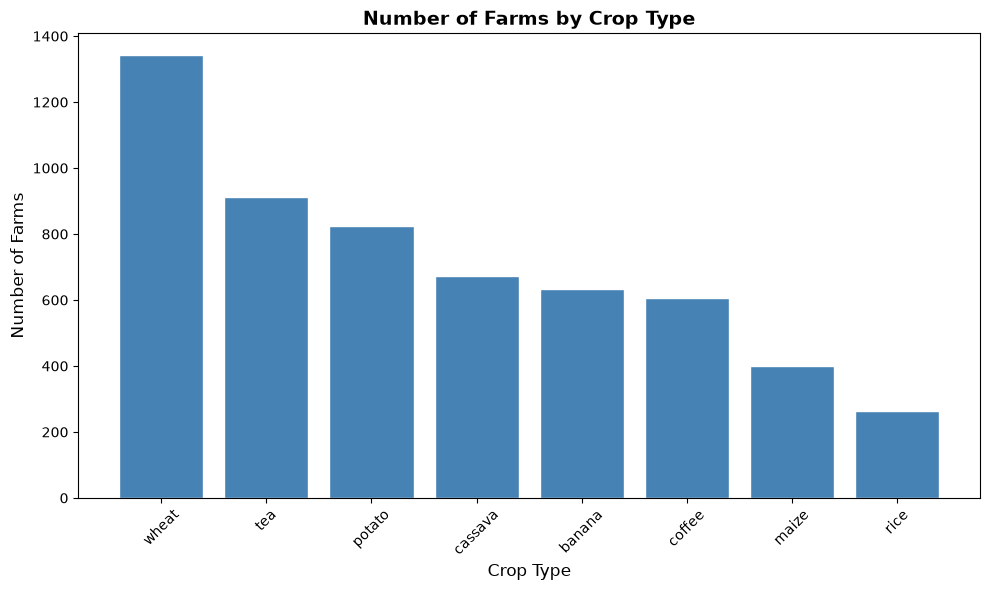

In [15]:
import matplotlib.pyplot as plt

crop_counts = merged_df['Crop_type'].value_counts()
print(crop_counts)

plt.figure(figsize=(10, 6))
plt.bar(crop_counts.index, crop_counts.values, color='steelblue', edgecolor='white')
plt.title('Number of Farms by Crop Type', fontsize=14, fontweight='bold')
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('Number of Farms', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
merged_df['yield_gap'] = merged_df['Standard_yield'] - merged_df['Annual_yield']
print(merged_df['yield_gap'].describe())

count    5654.000000
mean       -1.555994
std         1.913422
min       -11.843195
25%        -1.976168
50%        -0.922683
75%        -0.250542
max         0.390558
Name: yield_gap, dtype: float64


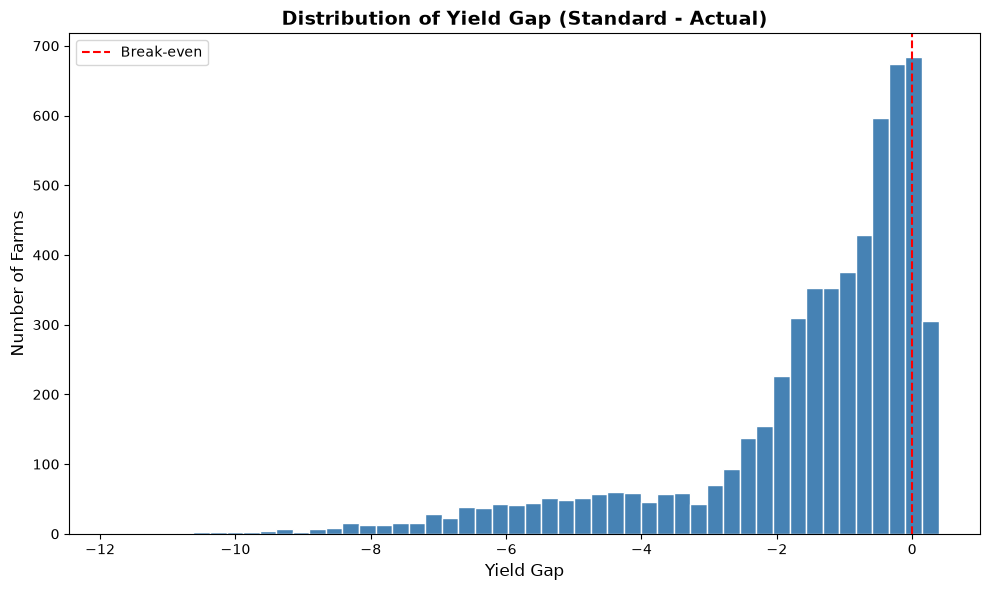

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(merged_df['yield_gap'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Yield Gap (Standard - Actual)', fontsize=14, fontweight='bold')
plt.xlabel('Yield Gap', fontsize=12)
plt.ylabel('Number of Farms', fontsize=12)
plt.axvline(0, color='red', linestyle='--', label='Break-even')
plt.legend()
plt.tight_layout()
plt.show()

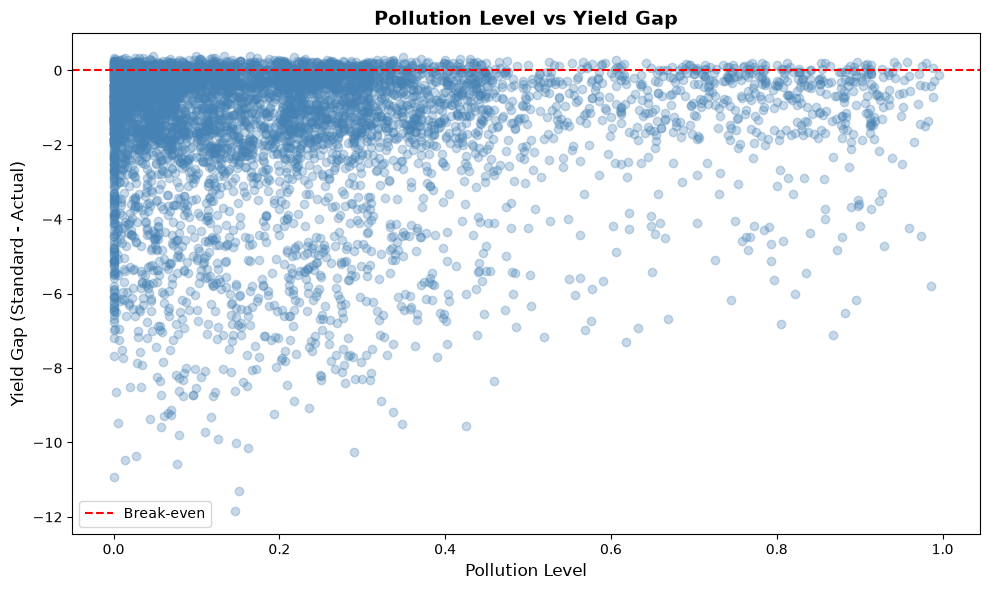

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['Pollution_level'], merged_df['yield_gap'], alpha=0.3, color='steelblue')
plt.title('Pollution Level vs Yield Gap', fontsize=14, fontweight='bold')
plt.xlabel('Pollution Level', fontsize=12)
plt.ylabel('Yield Gap (Standard - Actual)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', label='Break-even')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\gbemi\AppData\Local\Temp\ipykernel_6816\2733783475.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


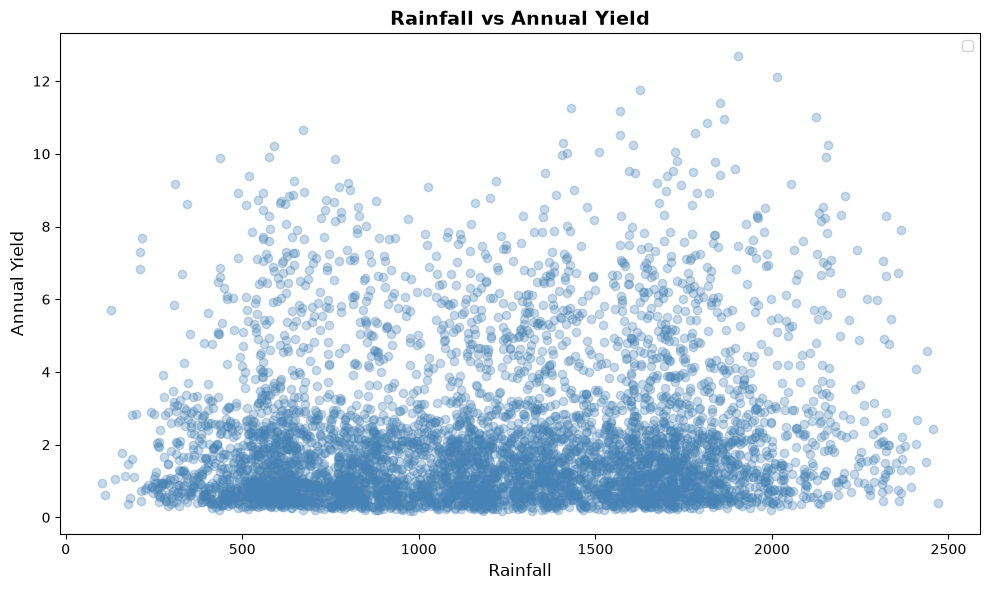

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['Rainfall'], merged_df['Annual_yield'], alpha=0.3, color='steelblue')
plt.title('Rainfall vs Annual Yield', fontsize=14, fontweight='bold')
plt.xlabel('Rainfall', fontsize=12)
plt.ylabel('Annual Yield', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

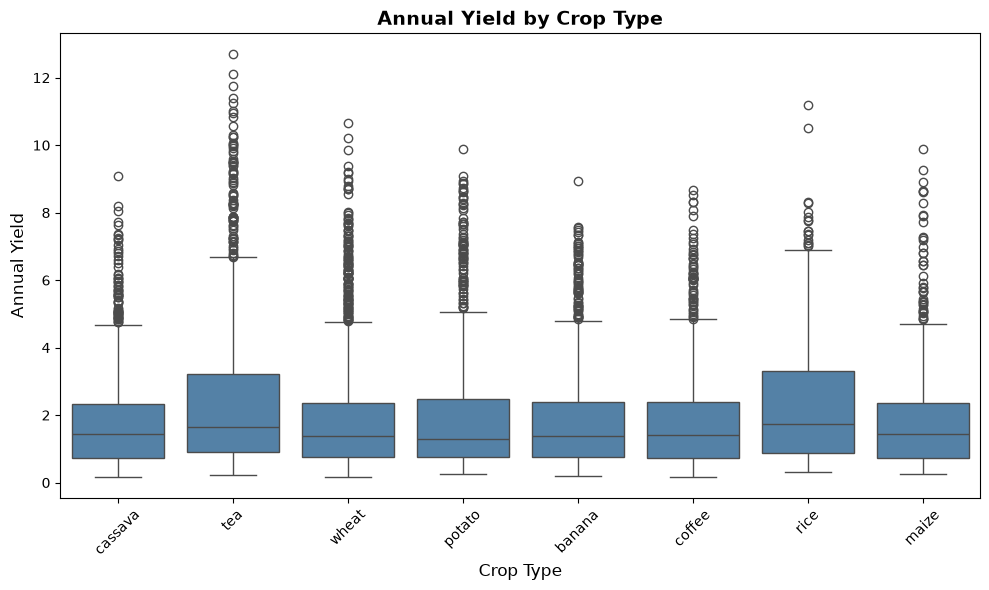

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, x='Crop_type', y='Annual_yield', color='steelblue')
plt.title('Annual Yield by Crop Type', fontsize=14, fontweight='bold')
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('Annual Yield', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
print(merged_df.groupby('Crop_type')['Annual_yield'].median().sort_values())

Crop_type
potato     1.283974
wheat      1.389082
banana     1.391763
coffee     1.405154
maize      1.446741
cassava    1.447799
tea        1.657955
rice       1.734914
Name: Annual_yield, dtype: float64


## 3. Key Findings

- **Crop distribution** — Wheat is the most cultivated crop (1,342 farms), rice the least (265 farms)
- **Yield performance** — The majority of farms exceed their standard yield, with only a small number underperforming
- **Pollution impact** — High pollution levels suppress yield potential; extreme overproformance only occurs at low pollution levels
- **Rainfall & yield** — Peak yields (10–12) only appear at high rainfall, but most farms cluster in the mid-rainfall range
- **Crop yield ranking** — Rice has the highest median yield, followed by tea. Potato has the lowest median yield

In [22]:
underperformers = merged_df[merged_df['yield_gap'] > 0]
print(underperformers.shape)

print("Underperformers - Pollution Level:")
print(underperformers['Pollution_level'].describe())

print("\nAll farms - Pollution Level:")
print(merged_df['Pollution_level'].describe())

(621, 19)
Underperformers - Pollution Level:
count    6.210000e+02
mean     2.352543e-01
std      2.311254e-01
min      1.126885e-09
25%      5.826559e-02
50%      1.860199e-01
75%      3.129347e-01
max      9.889643e-01
Name: Pollution_level, dtype: float64

All farms - Pollution Level:
count    5.654000e+03
mean     2.231923e-01
std      2.237976e-01
min      1.013245e-10
25%      5.133734e-02
50%      1.647056e-01
75%      3.058885e-01
max      9.954134e-01
Name: Pollution_level, dtype: float64


In [23]:
print("Underperformers - Rainfall:")
print(underperformers['Rainfall'].describe())

print("\nAll farms - Rainfall:")
print(merged_df['Rainfall'].describe())

Underperformers - Rainfall:
count     621.000000
mean     1150.865056
std       500.988506
min       175.200000
25%       704.700000
50%      1132.100000
75%      1592.900000
max      2470.900000
Name: Rainfall, dtype: float64

All farms - Rainfall:
count    5654.000000
mean     1201.943244
std       499.782824
min       103.100000
25%       773.175000
50%      1200.600000
75%      1625.425000
max      2470.900000
Name: Rainfall, dtype: float64


In [24]:
print("Underperformers - Soil Fertility:")
print(underperformers['Soil_fertility'].describe())

print("\nAll farms - Soil Fertility:")
print(merged_df['Soil_fertility'].describe())

Underperformers - Soil Fertility:
count    621.000000
mean       0.645894
std        0.044751
min        0.550000
25%        0.610000
50%        0.640000
75%        0.680000
max        0.820000
Name: Soil_fertility, dtype: float64

All farms - Soil Fertility:
count    5654.000000
mean        0.619308
std         0.044791
min         0.510000
25%         0.590000
50%         0.620000
75%         0.650000
max         0.820000
Name: Soil_fertility, dtype: float64


In [25]:
print(underperformers['Crop_type'].value_counts())
print()
print(merged_df['Crop_type'].value_counts())

Crop_type
wheat      152
tea        114
potato     103
banana      62
cassava     56
coffee      54
maize       52
rice        28
Name: count, dtype: int64

Crop_type
wheat      1342
tea         913
potato      823
cassava     672
banana      633
coffee      607
maize       399
rice        265
Name: count, dtype: int64


In [26]:
total_per_crop = merged_df['Crop_type'].value_counts()
under_per_crop = underperformers['Crop_type'].value_counts()

underperformance_rate = (under_per_crop / total_per_crop * 100).round(2).sort_values(ascending=False)
print(underperformance_rate)

Crop_type
maize      13.03
potato     12.52
tea        12.49
wheat      11.33
rice       10.57
banana      9.79
coffee      8.90
cassava     8.33
Name: count, dtype: float64


### Investigating Underperformers (621 farms, ~11% of total)

Compared underperforming farms against all farms across key variables:
- **Pollution** — slightly higher (0.235 vs 0.223) but marginal difference
- **Rainfall** — slightly lower (1,150 vs 1,201mm) but marginal difference  
- **Soil fertility** — underperformers actually have *higher* average fertility (0.646 vs 0.619)
- **Crop type** — maize has the highest underperformance rate (13%), cassava the lowest (8.3%), but the spread is narrow

**Conclusion:** No single factor explains underperformance. It is likely driven by a combination of conditions rather than one root cause.

## 4. Recommendations

Based on the analysis of 5,654 farms across the Maji Ndogo region:

1. **Prioritise pollution control** — High pollution levels suppress yield potential. Farms with high pollution never achieve extreme overperformance even under good conditions. Reducing pollution should be a priority intervention.

2. **Expand rice cultivation** — Rice has the highest median yield of all crops. Farmers currently growing lower-yielding crops like potato or wheat could be encouraged to consider rice where conditions allow.

3. **Investigate maize underperformance** — Maize has the highest underperformance rate (13%). A targeted study on maize farms specifically could uncover localised issues not visible in this dataset.

4. **Leverage high rainfall areas** — Peak yields only appear at high rainfall levels. Farms in high rainfall zones should be prioritised for investment and support to maximise their natural advantage.

5. **Further data collection needed** — Since no single factor explains underperformance, richer data (e.g. farming practices, irrigation, pest control) would help build a more complete picture.